In [1]:

import sys
sys.path.append("..")
from config import *
from scripts.compare_func_8points_mixed import *
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# Uncertainty Sampling

In [2]:
# List of datasets from config
datasets = [
    DATASET_10272_Ag_Au_Pd_RT,
    DATASET_10275_Ag_Au_Pd_Pt_Rh_RT,
    DATASET_10304_Au_Pd_Pt_Rh_RT,
    DATASET_10311_Au_Pd_Pt_Rh_Ru_RT,
    DATASET_10403_Ag_Au_Cu_Pd_Pt_RT, 
    DATASET_10402_Ag_Au_Pd_Pt_RT,
    DATASET_10399_Au_Cu_Pd_Pt_RT,
    DATASET_10374_Ir_Pd_Pt_Rh_Ru
]

In [3]:
material_ids = ["10374", "10399", "10402", "10403", "10311", "10304", "10275", "10272"]

base_root = UNCERTAINTY_PATH_8
mixed_folder =UNCERTAINTY_PATH

base_strategies = [
    "Centroids_saturation_high", "Random", "LHS", 
    "K-Means", "Farthest", "K-Center", "ODAL", 
    "Centroids_saturation_medium", "Centroids_saturation_low", "Top5Similarity"
]


# Folder where results will be saved
os.makedirs(base_mixed_Uncertainty, exist_ok=True)


df_comparison, overall_improvement_Similarity = compare_all_top5similarity_mix_with_top8(
    material_ids=material_ids,
    base_root=base_root,
    mixed_folder=mixed_folder
)
df_comparison.head()

Overall Improvement Rate: 58.82% (40/68)


,MaterialLibrary,MixedStrategy,MixedStoppingIteration,Top8StoppingIteration,ComparisonResult,ImprovementPercentage
0,10374,Top5Similarity+Max Comp,100,81,Worse,-19.0
1,10374,Top5Similarity+Min Comp,52,81,Improved,29.0
2,10374,Top5Similarity+Centroids_saturation_high,77,81,Improved,4.0
3,10374,Top5Similarity+Centroids_saturation_medium,47,81,Improved,34.0
4,10374,Top5Similarity+Centroids_saturation_low,49,81,Improved,32.0


In [4]:

summary = []
# Loop through each mixing strategy
for strategy in base_strategies:
    output_file_path = os.path.join(base_mixed_Uncertainty, f"{strategy}_mixed_vs_others.csv")

    df_comparison, overall_improvement, _ = compare_fixed_base_mixed_strategies(
            material_ids=material_ids,
            base_root=base_root,
            mixed_folder=mixed_folder,
            base_strategies=base_strategies,
            mixing_strategy=strategy,
            output_file=output_file_path
        )
    summary.append({
        "MixingStrategy": strategy,
        "OverallImprovementPercent": overall_improvement
    })

# Save summary of improvements

summary_df = pd.DataFrame(summary)

summary_df.loc[summary_df["MixingStrategy"] == "Top5Similarity", "OverallImprovementPercent"] = overall_improvement_Similarity

summary_df.to_csv(os.path.join(base_mixed_Uncertainty, "overall_summary.csv"), index=False)

save_path = os.path.join(base_mixed_Uncertainty, "Top5Similarity_mixed_vs_other.csv")

# Save DataFrame
df_comparison.to_csv(save_path, index=False)


Overall Improvement Rate for Centroids_saturation_high: 37.78% (17/45)

Overall Improvement Rate for Random: 46.67% (21/45)

Overall Improvement Rate for LHS: 43.75% (21/48)

Overall Improvement Rate for K-Means: 66.0% (33/50)

Overall Improvement Rate for Farthest: 61.54% (32/52)

Overall Improvement Rate for K-Center: 60.78% (31/51)

Overall Improvement Rate for ODAL: 67.31% (35/52)

Overall Improvement Rate for Centroids_saturation_medium: 35.71% (15/42)

Overall Improvement Rate for Centroids_saturation_low: 38.1% (16/42)

Overall Improvement Rate for Top5Similarity: 56.6% (30/53)


In [5]:
merge_all_summaries(input_folder=base_mixed_Uncertainty)

,CanonicalMixedStrategy,MaxImprovedCount
2,Centroids_saturation_high+Farthest,6
25,Farthest+K-Means,6
4,Centroids_saturation_high+K-Means,6
17,Centroids_saturation_medium+Farthest,6
39,LHS+ODAL,6
38,K-Means+Top5Similarity,5
11,Centroids_saturation_low+K-Center,5
35,K-Means+LHS,5
21,Centroids_saturation_medium+ODAL,5
18,Centroids_saturation_medium+K-Center,5


# SWEI 

In [6]:
base_root = SAWEI_PATH_8
mixed_folder =SAWEI_PATH
# Folder where results will be saved
os.makedirs(base_mixed_SAWEI, exist_ok=True)


df_comparison, overall_improvement_Similarity = compare_all_top5similarity_mix_with_top8(
    material_ids=material_ids,
    base_root=base_root,
    mixed_folder=mixed_folder
)
df_comparison.head()

Overall Improvement Rate: 61.19% (41/67)


,MaterialLibrary,MixedStrategy,MixedStoppingIteration,Top8StoppingIteration,ComparisonResult,ImprovementPercentage
0,10374,Top5Similarity+Max Comp,100,81,Worse,-19.0
1,10374,Top5Similarity+Min Comp,52,81,Improved,29.0
2,10374,Top5Similarity+Centroids_saturation_high,77,81,Improved,4.0
3,10374,Top5Similarity+Centroids_saturation_medium,47,81,Improved,34.0
4,10374,Top5Similarity+Centroids_saturation_low,49,81,Improved,32.0


In [7]:
summary = []

# Loop through each mixing strategy
for strategy in base_strategies:
    output_file_path = os.path.join(base_mixed_SAWEI, f"{strategy}_mixed_vs_others.csv")

    df_comparison, overall_improvement, _ = compare_fixed_base_mixed_strategies(
            material_ids=material_ids,
            base_root=base_root,
            mixed_folder=mixed_folder,
            base_strategies=base_strategies,
            mixing_strategy=strategy,
            output_file=output_file_path
        )
    summary.append({
        "MixingStrategy": strategy,
        "OverallImprovementPercent": overall_improvement
    })

# Save summary of improvements

summary_df = pd.DataFrame(summary)

summary_df.loc[summary_df["MixingStrategy"] == "Top5Similarity", "OverallImprovementPercent"] = overall_improvement_Similarity

summary_df.to_csv(os.path.join(base_mixed_SAWEI, "overall_summary.csv"), index=False)

save_path = os.path.join(base_mixed_SAWEI, "Top5Similarity_mixed_vs_other.csv")

# Save DataFrame
df_comparison.to_csv(save_path, index=False)


Overall Improvement Rate for Centroids_saturation_high: 37.21% (16/43)

Overall Improvement Rate for Random: 61.36% (27/44)

Overall Improvement Rate for LHS: 41.46% (17/41)

Overall Improvement Rate for K-Means: 56.25% (27/48)

Overall Improvement Rate for Farthest: 64.15% (34/53)

Overall Improvement Rate for K-Center: 64.0% (32/50)

Overall Improvement Rate for ODAL: 67.35% (33/49)

Overall Improvement Rate for Centroids_saturation_medium: 40.48% (17/42)

Overall Improvement Rate for Centroids_saturation_low: 38.46% (15/39)

Overall Improvement Rate for Top5Similarity: 58.18% (32/55)


In [8]:
merge_all_summaries(input_folder=base_mixed_SAWEI)

,CanonicalMixedStrategy,MaxImprovedCount
10,Centroids_saturation_low+Farthest,6
17,Centroids_saturation_medium+Farthest,6
4,Centroids_saturation_high+K-Means,6
26,Farthest+LHS,6
21,Centroids_saturation_medium+ODAL,5
30,K-Center+K-Means,5
14,Centroids_saturation_low+ODAL,5
38,K-Means+Top5Similarity,5
11,Centroids_saturation_low+K-Center,5
22,Centroids_saturation_medium+Random,5


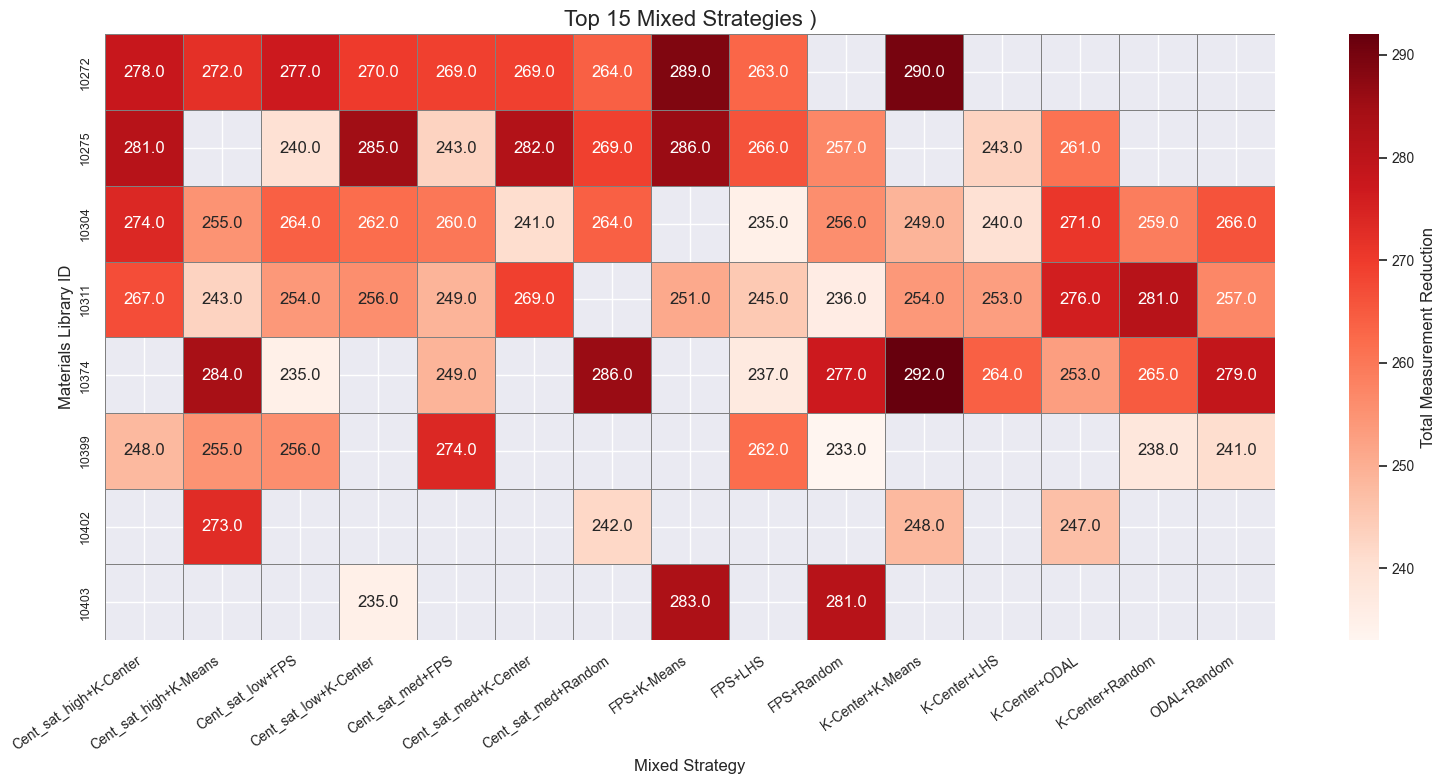

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from glob import glob
import matplotlib.ticker as ticker

# Mapping for shorter display names
STRATEGY_DISPLAY_NAMES = {
    "Centroids_saturation_high": "Cent_sat_high",
    "Centroids_saturation_medium": "Cent_sat_med",
    "Centroids_saturation_low": "Cent_sat_low",
    "Top5Similarity": "T5S",
    "Max Comp": "Max Comp",
    "Min Comp": "Min Comp",
    "Random": "Random",
    "LHS": "LHS",
    "K-Means": "K-Means",
    "Farthest": "FPS",
    "K-Center": "K-Center",
    "ODAL": "ODAL"
}

def generate_mixed_strategy_heatmap(data_folder, pattern="*_mixed_vs_others.csv",
                                     stopping_iteration=232, top_k=30,
                                     save_path=None):
    all_data = []

    for file in glob(os.path.join(data_folder, pattern)):
        df = pd.read_csv(file)
        if not {"MaterialLibrary", "CanonicalMixedStrategy", "ImprovementPercentage"}.issubset(df.columns):
            print(f"Skipping {file}, missing columns.")
            continue
        all_data.append(df)

    if not all_data:
        print("No valid input data found.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)

    # ✅ Only keep positive improvements
    combined_df = combined_df[combined_df["ImprovementPercentage"] > 0]

    if combined_df.empty:
        print("No positive improvements found.")
        return

    # ✅ Replace with Improvement + stopping iteration (default 232)
    combined_df["MixedStopValue"] = combined_df["ImprovementPercentage"] + stopping_iteration

    # --- Normalize and map strategy names for display ---
    def normalize_strategy_name(name):
        parts = name.split('+')
        normalized = '+'.join(sorted(parts))  # Sort to avoid duplicates like A+B vs B+A
        display_parts = [STRATEGY_DISPLAY_NAMES.get(p, p) for p in normalized.split('+')]
        return '+'.join(display_parts)

    combined_df["DisplayStrategy"] = combined_df["CanonicalMixedStrategy"].apply(normalize_strategy_name)

    # --- Find top-k strategies by total MixedStopValue ---
    top_strategies = (
        combined_df.groupby("DisplayStrategy")["MixedStopValue"]
        .sum()
        .sort_values(ascending=False)
        .head(top_k)
        .index.tolist()
    )

    # Filter to only include top-k strategies
    filtered_df = combined_df[combined_df["DisplayStrategy"].isin(top_strategies)]

    # Pivot to create heatmap matrix
    heatmap_data = filtered_df.pivot_table(
        index="MaterialLibrary",
        columns="DisplayStrategy",
        values="MixedStopValue",
        aggfunc="max"
    )

    if heatmap_data.empty:
        print("No heatmap data after filtering.")
        return

    # --- Plotting ---
    plt.figure(figsize=(max(16, top_k * 0.8), 8))
    sns.set_theme(style="whitegrid")
    sns.set(font_scale=1.0 if top_k <= 20 else 0.85)

    ax = sns.heatmap(
        heatmap_data,
        annot=top_k <= 20,
        fmt=".1f",
        cmap="Reds",
        cbar_kws={'label': 'Total Measurement Reduction'},
        linewidths=0.4,
        linecolor='gray'
    )

    # Axis and title
    ax.set_title(f"Top {top_k} Mixed Strategies )", fontsize=16)
    ax.set_ylabel("Materials Library ID", fontsize=12)
    ax.set_xlabel("Mixed Strategy", fontsize=12)

    # X-axis ticks
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

    # Clean up spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Optional: customize colorbar ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}"))

    # Final layout
    plt.tight_layout()

    # Save (optional)
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', pad_inches=0.1)
        print(f"Heatmap saved to {save_path}")

    plt.show()



generate_mixed_strategy_heatmap(base_mixed_SAWEI, pattern="*_mixed_vs_others.csv", top_k=15)

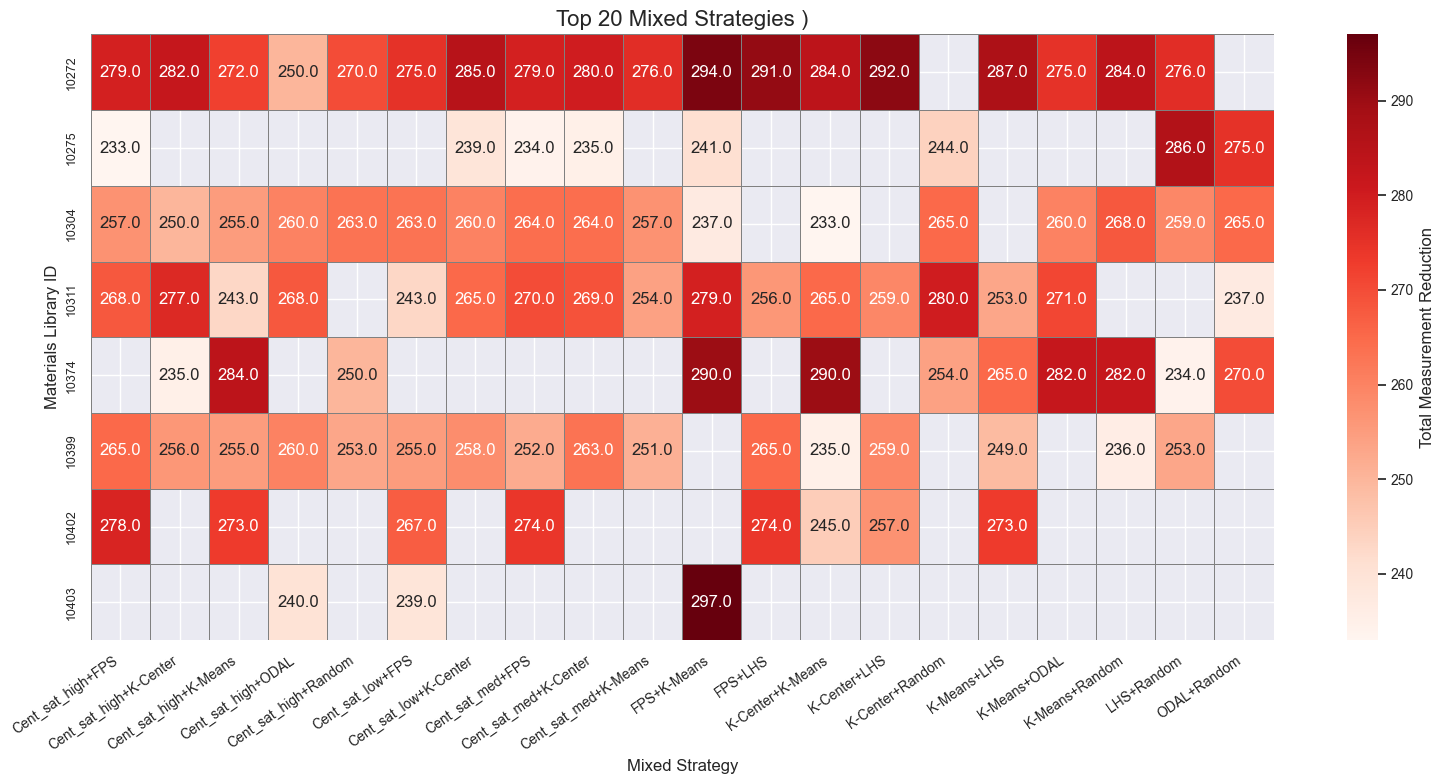

In [20]:
generate_mixed_strategy_heatmap(base_mixed_Uncertainty, pattern="*_mixed_vs_others.csv", top_k=20)